# 03. Brand classifier — EDA + silver (с NO_BRAND / UNKNOWN)

Цель: silver для query→brand **с отказом**, чтобы не учить `холодильник → Indesit`.

Бейзлайн [`07_train_baseline_classifier.ipynb`](../07_train_baseline_classifier.ipynb) брал first-click top-80 без reject-класса.

Здесь:

1. Majority brand + вес позиции  
2. `query_norm` (`basic_clean`)  
3. Сигналы evidence: brand/alias в тексте, category-only  
4. Классы: **топ-K бренды** + **`NO_BRAND`** + **`UNKNOWN`**  
5. Явная **inference policy** (когда звать clf и с какими τ)  
6. Артефакты → `artifacts/brand_clf/`

Договорённости / OOD / confidence / подводные камни:  
[`silver_clf_readme.md`](./silver_clf_readme.md).

Clf — **fallback**, не обязательный ответ на каждый запрос.


## 0. Setup

In [1]:
%matplotlib inline
import sys
import json
import re
import ast
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path.cwd().resolve()
if ROOT.name in {"preprocessing", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "preprocessing" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style,
    ensure_dirs,
    load_query_clicks,
    ARTIFACTS_DIR,
    FIGURES_DIR,
    MVIDEO_RED,
    DARK_SLATE,
    MUTED,
    save_stats,
)
from src.preprocessing.pipeline import basic_clean, _norm_key

def _load_brand_aliases() -> dict:
    tree = ast.parse((ROOT / "src" / "ner" / "labeling.py").read_text(encoding="utf-8"))
    for node in tree.body:
        if isinstance(node, ast.Assign):
            for t in node.targets:
                if getattr(t, "id", None) == "BRAND_ALIASES":
                    return ast.literal_eval(node.value)
    return {}

BRAND_ALIASES = _load_brand_aliases()

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "preprocessing" / "brand_clf"
OUT = ARTIFACTS_DIR / "brand_clf"
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)
print("OUT:", OUT)
print("aliases:", len(BRAND_ALIASES))


ROOT: D:\Projects-26-06-2026\mvideo-ner-search
OUT: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf
aliases: 36


## 1. Конфиг: данные + пороги silver + пороги inference

`NO_BRAND` / `UNKNOWN` — специальные лейблы (не бренды каталога).


In [2]:
# --- data ---
SAMPLE_N = 400_000
SEED = 42

# --- closed-set brands ---
TOP_K_BRANDS = 80
MIN_CLICKS = 1
MIN_CONFIDENCE = 0.55          # majority weight share для позитивного бренда
REQUIRE_SINGLE_BRAND = False

# --- special labels ---
LABEL_NO_BRAND = "NO_BRAND"    # бренда в запросе нет и не подразумевается
LABEL_UNKNOWN = "UNKNOWN"      # бренд вне top-K / спорный / OOD

# --- silver construction ---
HIGH_CONF = 0.75
MED_CONF = 0.55
NO_BRAND_MAX_TOKENS = 4        # «холодильник», «стиральная машина»
NO_BRAND_TARGET_SHARE = 0.18   # доля NO_BRAND в silver (downsample/upsample ориентир)
UNKNOWN_FROM_TAIL = True       # majority вне top-K → UNKNOWN
KEEP_ALIAS_WITHOUT_SURFACE = True  # «айфон 15» без слова Apple → всё же класс Apple

# --- train split ---
VAL_SIZE = 0.2
MIN_PER_CLASS_TRAIN = 15

# --- inference policy (когда ЗВАТЬ clf и когда ПРИНЯТЬ ответ) ---
# Эти же числа пишем в artifacts/brand_clf/inference_policy.json
TAU_ACCEPT = 0.42          # min P(top-1), иначе reject → brand=null
TAU_MARGIN = 0.08          # min P(top-1)-P(top-2)
TAU_NO_BRAND = 0.35        # если P(NO_BRAND) ≥ τ → brand=null
TAU_UNKNOWN = 0.30         # если pred=UNKNOWN и P≥τ → brand=null + flag ood
REQUIRE_BRAND_EVIDENCE = True  # не звать clf на чистом category-only

SAVE = True


## 1b. Когда использовать clf (критерии + пороги)

### Cascade (обязательный порядок)

```text
query → preprocess → NER/dicts (BRAND / alias)
  │
  ├─ найден B-BRAND (или alias→canonical)  →  brand = span/alias,  clf НЕ звать
  │
  ├─ category-only (холодильник, наушники) →  brand = null (NO_BRAND), clf НЕ звать
  │     признак: есть категория, нет brand/alias surface, короткий запрос
  │
  ├─ есть brand-evidence, но span пуст
  │     evidence = alias («айфон») ИЛИ model-ish хвост с намёком на бренд
  │     →  звать clf
  │
  └─ иначе (мусор / слишком общий) → brand = null, clf НЕ звать
```

### Если clf вызван — принять предсказание только если

| Условие | Порог (дефолт) | Действие |
|---|---|---|
| `pred ∈ top-K brands` и `P(pred) ≥ TAU_ACCEPT` и `margin ≥ TAU_MARGIN` | 0.42 / 0.08 | принять brand |
| `pred == NO_BRAND` и `P ≥ TAU_NO_BRAND` | 0.35 | `brand = null` |
| `pred == UNKNOWN` и `P ≥ TAU_UNKNOWN` | 0.30 | `brand = null`, флаг OOD (retrieval) |
| иначе | — | **reject**: `brand = null` (не форсировать Indesit) |

### Зачем так
- Без `NO_BRAND` модель обязана ткнуть в частый бренд на `холодильник`.  
- Без reject по τ — низкая уверенность всё равно попадёт в JSON.  
- Новый бренд вне top-K → `UNKNOWN`, не «ближайший» Samsung.


## 2. Загрузка кликов + EDA сырья


In [3]:
clicks = load_query_clicks(
    n=SAMPLE_N,
    seed=SEED,
    random=True,
    columns=["query_text", "sku_brand_name", "sku_position", "sku_name"],
)
clicks["query_text"] = clicks["query_text"].fillna("").astype(str).str.strip()
clicks["sku_brand_name"] = clicks["sku_brand_name"].fillna("").astype(str).str.strip()
clicks["sku_position"] = pd.to_numeric(clicks["sku_position"], errors="coerce").fillna(99).astype(int)

raw = clicks[
    (clicks["query_text"].str.len() >= 2) & (clicks["sku_brand_name"].str.len() >= 2)
].copy()
print(f"clicks sample: {len(clicks):,}  |  with query+brand: {len(raw):,}")
print(f"unique queries: {raw['query_text'].nunique():,}")
print(f"unique brands:  {raw['sku_brand_name'].nunique():,}")

n_brands_per_q = raw.groupby("query_text")["sku_brand_name"].nunique()
print(f"queries with ≥2 click-brands: {(n_brands_per_q >= 2).mean():.1%}")
display(raw["sku_brand_name"].value_counts().head(15).to_frame("clicks"))


clicks sample: 400,000  |  with query+brand: 286,649
unique queries: 70,537
unique brands:  3,785
queries with ≥2 click-brands: 10.8%


,clicks
sku_brand_name,
Apple,18451
Samsung,16815
Haier,9663
Xiaomi,9413
HUAWEI,9130
Tefal,6905
Gorenje,5900
Яндекс,5444
Indesit,4788


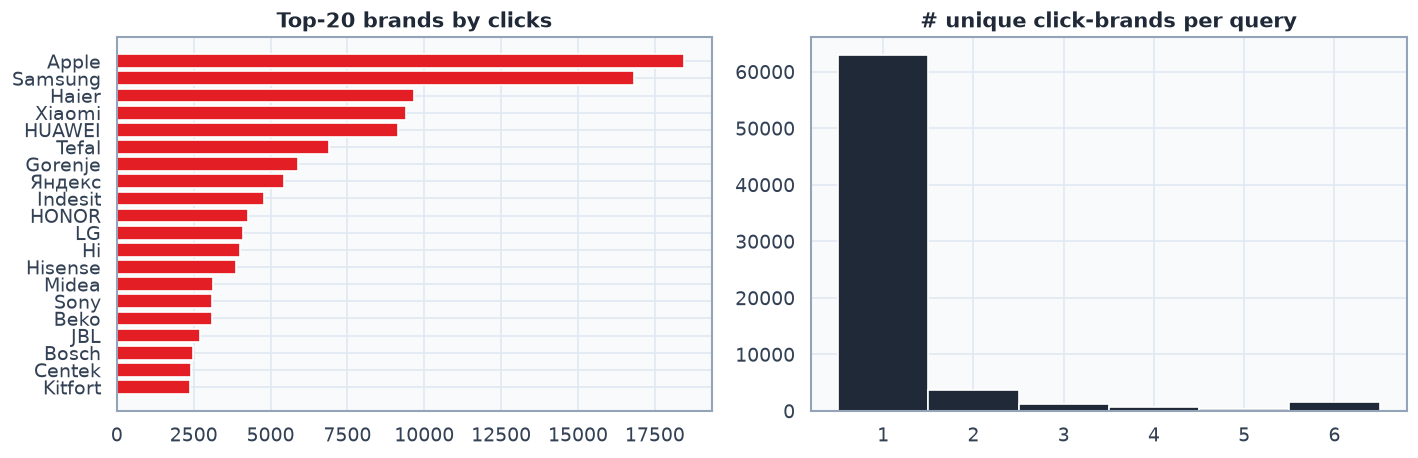

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = raw["sku_brand_name"].value_counts()
axes[0].barh(vc.head(20).index[::-1], vc.head(20).values[::-1], color=MVIDEO_RED)
axes[0].set_title("Top-20 brands by clicks")
axes[1].hist(n_brands_per_q.clip(upper=6), bins=np.arange(0.5, 7.5, 1), color=DARK_SLATE, edgecolor="white")
axes[1].set_title("# unique click-brands per query")
fig.tight_layout()
fig.savefig(FIG / "01_raw_brand_dist.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Preprocess


In [5]:
uniq_queries = raw["query_text"].drop_duplicates().tolist()
print(f"preprocess {len(uniq_queries):,} unique queries…")
norm_map = {q: _norm_key(basic_clean(q, lowercase=False)) for q in uniq_queries}
raw["query_norm"] = raw["query_text"].map(norm_map)
print("unique query_norm:", raw["query_norm"].nunique())
for q in uniq_queries[:5]:
    print(f"  {q!r}  →  {norm_map[q]!r}")


preprocess 70,537 unique queries…
unique query_norm: 63267
  'тумбочка'  →  'тумбочка'
  'Indesit ITS 4180 W'  →  'indesit its 4180 w'
  'кондиционер сплит система'  →  'кондиционер сплит система'
  'ноутбук'  →  'ноутбук'
  'наушники внутрение беспроводные'  →  'наушники внутрение беспроводные'


## 4. Majority brand


In [6]:
def aggregate_majority(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for qn, g in df.groupby("query_norm", sort=False):
        brands = g["sku_brand_name"].tolist()
        positions = g["sku_position"].tolist()
        raw_queries = g["query_text"].tolist()
        weights = defaultdict(float)
        counts = Counter()
        for b, pos in zip(brands, positions):
            w = 1.0 / (1.0 + max(int(pos), 0))
            weights[b] += w
            counts[b] += 1
        total_w = sum(weights.values())
        maj, maj_w = max(weights.items(), key=lambda kv: (kv[1], counts[kv[0]]))
        ranked = sorted(weights.items(), key=lambda kv: kv[1], reverse=True)
        runner = ranked[1][0] if len(ranked) > 1 else None
        runner_w = ranked[1][1] if len(ranked) > 1 else 0.0
        q_raw = Counter(raw_queries).most_common(1)[0][0]
        rows.append({
            "query_norm": qn,
            "query_raw": q_raw,
            "click_brand": maj,
            "confidence": maj_w / total_w if total_w else 0.0,
            "n_clicks": len(g),
            "n_brands": len(weights),
            "brand_click_count": counts[maj],
            "runner_up": runner,
            "runner_up_share": runner_w / total_w if total_w else 0.0,
            "weight_margin": (maj_w - runner_w) / total_w if total_w else 0.0,
        })
    return pd.DataFrame(rows)

agg = aggregate_majority(raw)
print(agg.shape)
display(agg.sort_values("n_clicks", ascending=False).head(8))
print(agg["confidence"].describe().round(3))


(63267, 10)


,query_norm,query_raw,click_brand,confidence,n_clicks,n_brands,brand_click_count,runner_up,runner_up_share,weight_margin
24,стиральная машинка,стиральная машинка,Indesit,0.211995,5587,81,1054,Haier,0.152484,0.059511
15,холодильники,холодильники,Indesit,0.235028,4998,91,931,Hi,0.146123,0.088905
8,аэрогриль,аэрогриль,DEMIAND,0.187299,3634,105,561,Tefal,0.179378,0.007921
2,кондиционер сплит система,кондиционер сплит система,Rapid,0.185763,2398,71,298,Haier,0.169694,0.016069
73,микроволновая печь,микроволновая печь,Gorenje,0.290346,2303,69,456,BBK,0.131277,0.159069
175,пылесос,пылесос,Tefal,0.222282,2210,122,372,Samsung,0.186231,0.036051
201,телевизор,телевизор,Hi,0.182069,2175,53,301,Haier,0.124632,0.057437
3,ноутбук,ноутбук,ASUS,0.248357,2126,47,491,Lenovo,0.101451,0.146905


count    63267.000
mean         0.959
std          0.136
min          0.103
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: confidence, dtype: float64


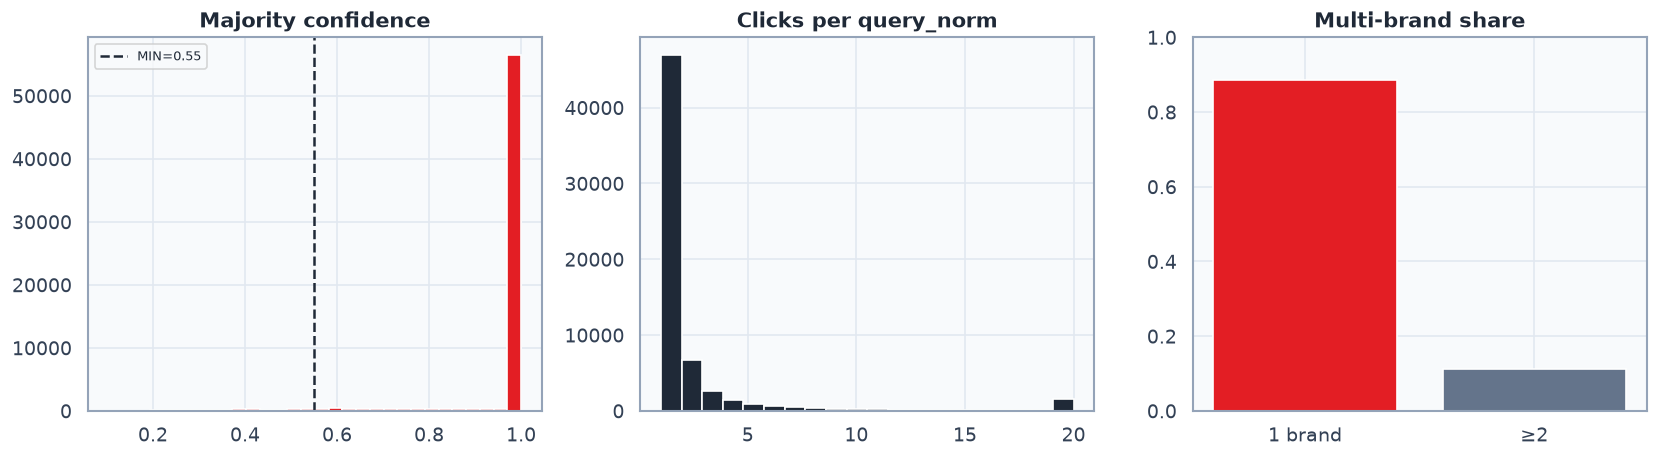

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(agg["confidence"], bins=30, color=MVIDEO_RED, edgecolor="white")
axes[0].axvline(MIN_CONFIDENCE, color=DARK_SLATE, ls="--", label=f"MIN={MIN_CONFIDENCE}")
axes[0].legend(fontsize=8); axes[0].set_title("Majority confidence")
axes[1].hist(agg["n_clicks"].clip(upper=20), bins=20, color=DARK_SLATE, edgecolor="white")
axes[1].set_title("Clicks per query_norm")
axes[2].bar(["1 brand", "≥2"], [(agg["n_brands"] == 1).mean(), (agg["n_brands"] >= 2).mean()], color=[MVIDEO_RED, MUTED])
axes[2].set_ylim(0, 1); axes[2].set_title("Multi-brand share")
fig.tight_layout()
fig.savefig(FIG / "02_majority_confidence.png", dpi=140, bbox_inches="tight")
plt.show()


## 5. Evidence-фичи: brand / alias / category-only

Без этих фич нельзя отличить `айфон 15` (нужен clf/alias) от `холодильник` (нужен `NO_BRAND`).


In [8]:
# --- lexicons ---
_alias_to_canon = {a.lower(): c for a, c in BRAND_ALIASES.items()}
_canon_to_aliases: dict[str, set[str]] = defaultdict(set)
for a, c in BRAND_ALIASES.items():
    _canon_to_aliases[c.lower()].add(a.lower())
    _canon_to_aliases[c.lower()].add(c.lower())

# Полный словарь категорий из артефакта (без ручного EXTRA_CATS)
_cat_stop = {
    "для", "и", "с", "на", "по", "из", "или", "the", "a", "of", "to",
    "в", "без", "под", "над", "при", "от", "до", "как", "все", "всё",
}
cat_lines = [
    _norm_key(x)
    for x in (ARTIFACTS_DIR / "categories.txt").read_text(encoding="utf-8").splitlines()
    if len(_norm_key(x)) >= 3
]
CATEGORY_PHRASES = sorted(set(cat_lines), key=len, reverse=True)
CATEGORY_TOKENS: set[str] = set()
for p in CATEGORY_PHRASES:
    for t in p.split():
        if len(t) >= 3 and t not in _cat_stop:
            CATEGORY_TOKENS.add(t)
print(f"categories: {len(CATEGORY_PHRASES)} phrases, {len(CATEGORY_TOKENS)} tokens")

ALIAS_KEYS = sorted(set(BRAND_ALIASES.keys()), key=len, reverse=True)


def _word_in(q: str, key: str) -> bool:
    if len(key) < 2:
        return False
    return re.search(rf"(?<!\w){re.escape(key)}(?!\w)", q) is not None


def brand_mentioned_in_text(query_norm: str, brand: str) -> bool:
    if not query_norm or not brand:
        return False
    q = query_norm.lower()
    b = brand.strip().lower()
    keys = set(_canon_to_aliases.get(b, set())) | {b}
    if b in _alias_to_canon:
        canon = _alias_to_canon[b].lower()
        keys |= _canon_to_aliases.get(canon, set()) | {canon}
    return any(_word_in(q, k) for k in keys)


def any_alias_in_query(query_norm: str) -> tuple[bool, str | None]:
    q = (query_norm or "").lower()
    for a in ALIAS_KEYS:
        if _word_in(q, a.lower()):
            return True, _alias_to_canon.get(a.lower(), BRAND_ALIASES.get(a))
    return False, None


def category_only_score(query_norm: str) -> dict:
    """Эвристика: запрос ≈ категория без brand/alias."""
    q = (query_norm or "").lower().strip()
    toks = [t for t in re.findall(r"[a-zа-яё0-9]+", q) if t]
    if not toks:
        return {"is_category_only": False, "cat_cover": 0.0, "n_tok": 0}
    has_alias, _ = any_alias_in_query(q)
    # цифры / латинские коды моделей снижают «чисто категорию»
    has_modelish = any(re.search(r"\d", t) for t in toks) or any(
        re.fullmatch(r"[a-z]{1,3}\d+[a-z0-9]*", t) for t in toks
    )
    cat_hits = sum(1 for t in toks if t in CATEGORY_TOKENS)
    cover = cat_hits / len(toks)
    is_co = (
        (not has_alias)
        and (not has_modelish)
        and len(toks) <= NO_BRAND_MAX_TOKENS
        and cover >= 0.6
    )
    return {
        "is_category_only": bool(is_co),
        "cat_cover": float(cover),
        "n_tok": len(toks),
        "has_modelish": bool(has_modelish),
    }


# top-K brands by click mass (для closed-set)
brand_mass = agg.groupby("click_brand")["n_clicks"].sum().sort_values(ascending=False)
top_brands = set(brand_mass.head(TOP_K_BRANDS).index)
print("top brands:", list(brand_mass.head(8).index))

rows = []
for r in agg.itertuples(index=False):
    qn = r.query_norm
    biq = brand_mentioned_in_text(qn, r.click_brand)
    has_alias, alias_canon = any_alias_in_query(qn)
    co = category_only_score(qn)
    rows.append({
        **r._asdict(),
        "brand_in_query": biq,
        "has_alias": has_alias,
        "alias_canon": alias_canon,
        "is_category_only": co["is_category_only"],
        "cat_cover": co["cat_cover"],
        "has_modelish": co["has_modelish"],
        "click_in_topk": r.click_brand in top_brands,
    })

feat = pd.DataFrame(rows)
print(feat[["brand_in_query", "has_alias", "is_category_only"]].mean().round(3))
print("category-only examples:")
display(feat.loc[feat["is_category_only"], ["query_norm", "click_brand", "confidence"]].head(10))
print("alias examples:")
display(feat.loc[feat["has_alias"], ["query_norm", "click_brand", "alias_canon", "confidence"]].head(10))


categories: 1010 phrases, 795 tokens
top brands: ['Apple', 'Indesit', 'Samsung', 'Tefal', 'Xiaomi', 'HUAWEI', 'Gorenje', 'Haier']
brand_in_query      0.418
has_alias           0.178
is_category_only    0.112
dtype: float64
category-only examples:


,query_norm,click_brand,confidence
2,кондиционер сплит система,Rapid,0.185763
3,ноутбук,ASUS,0.248357
4,наушники внутрение беспроводные,Havit,1.000000
6,водонагреватель,Ariston,0.179154
7,стайлер,Dyson,0.186528
8,аэрогриль,DEMIAND,0.187299
10,наушники,HUAWEI,0.168667
14,моющий пылесос,Thomas,0.112367
15,холодильники,Indesit,0.235028
19,ледогенератор,Brayer,0.277283


alias examples:


,query_norm,click_brand,alias_canon,confidence
16,смартфон xiaomi redmi note 15 pro plus телефон,Xiaomi,Xiaomi,1.000000
17,macbook,Apple,Apple,1.000000
33,планшет huawei,HUAWEI,HUAWEI,1.000000
35,samsung s26 ultra,Samsung,Samsung,0.988922
45,ноутбук acer aspire lite al15-42 p r601,Acer,Acer,1.000000
46,macbook neo,Apple,Apple,1.000000
47,самсунг смарт тв,Samsung,Samsung,1.000000
56,роботы пылесосы xiaomi,Xiaomi,Xiaomi,0.953701
64,внешний аккумулятор xiaomi,Xiaomi,Xiaomi,0.980770
66,смартфон samsung galaxy a36 5 g 8 256 гб,Samsung,Samsung,1.000000


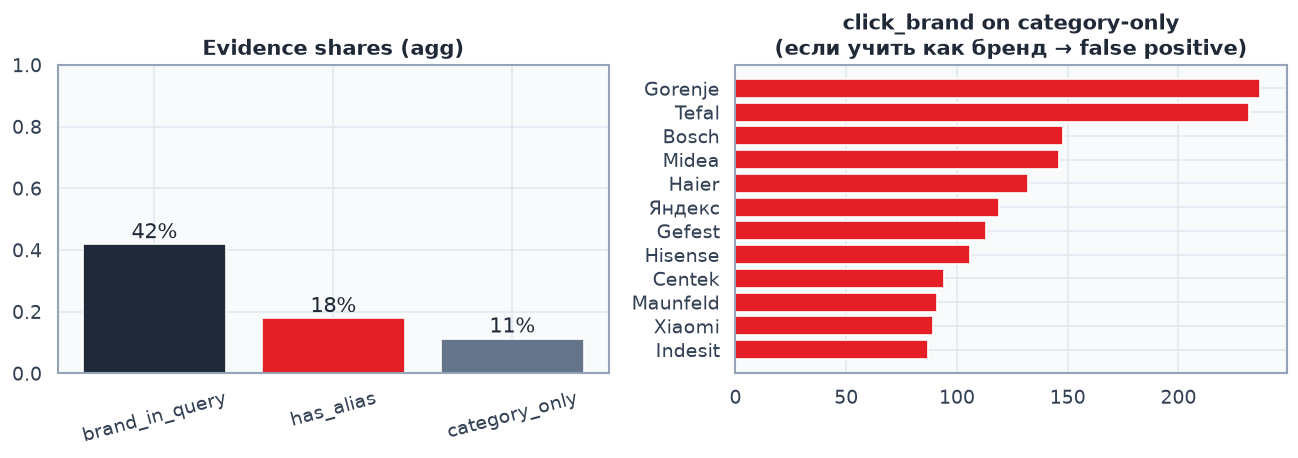

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
share = pd.Series({
    "brand_in_query": feat["brand_in_query"].mean(),
    "has_alias": feat["has_alias"].mean(),
    "category_only": feat["is_category_only"].mean(),
})
axes[0].bar(share.index, share.values, color=[DARK_SLATE, MVIDEO_RED, MUTED])
axes[0].set_ylim(0, 1)
axes[0].set_title("Evidence shares (agg)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(share.values):
    axes[0].text(i, v + 0.02, f"{v:.0%}", ha="center")

# опасный кейс: category-only, но click = частый бренд
danger = feat[feat["is_category_only"]]
axes[1].barh(
    danger["click_brand"].value_counts().head(12).index[::-1],
    danger["click_brand"].value_counts().head(12).values[::-1],
    color=MVIDEO_RED,
)
axes[1].set_title("click_brand on category-only\n(если учить как бренд → false positive)")
fig.tight_layout()
fig.savefig(FIG / "03_brand_in_query.png", dpi=140, bbox_inches="tight")
plt.show()


## 6. Сборка silver с NO_BRAND / UNKNOWN

### Правила лейбла `y`

| Условие | `y` | Зачем |
|---|---|---|
| category-only | `NO_BRAND` | не учить `холодильник→Indesit` |
| brand/alias в тексте **или** alias-hint, click∈top-K, conf≥τ | `click_brand` (или `alias_canon` если alias сильнее) | позитив |
| click∉top-K, conf≥τ, есть brand surface | `UNKNOWN` | open-set |
| brand_absent, нет alias, не category-only | **дроп** (не в silver) | слишком шумно для clf |
| низкий conf / multi-brand без surface | `UNKNOWN` или дроп | не форсировать majority |

Alias без surface бренда (`айфон`→Apple): если `KEEP_ALIAS_WITHOUT_SURFACE` и click/alias согласованы — позитивный класс Apple.


In [10]:
def assign_label(r) -> tuple[str | None, str]:
    """→ (label or None=drop, reason)."""
    # 1) явный category-only → NO_BRAND
    if r["is_category_only"]:
        return LABEL_NO_BRAND, "category_only"

    conf_ok = r["confidence"] >= MIN_CONFIDENCE and r["n_clicks"] >= MIN_CLICKS
    if REQUIRE_SINGLE_BRAND and r["n_brands"] > 1:
        conf_ok = conf_ok and r["confidence"] >= HIGH_CONF

    # 2) alias hint (айфон) — предпочитаем канон алиаса, если клик согласен или клик пустой сигнал
    if KEEP_ALIAS_WITHOUT_SURFACE and r["has_alias"] and r["alias_canon"]:
        canon = r["alias_canon"]
        if canon in top_brands and (
            r["click_brand"].lower() == canon.lower()
            or r["confidence"] >= MIN_CONFIDENCE
        ):
            # если клик сильно противоречит алиасу — UNKNOWN
            if r["click_brand"].lower() != canon.lower() and r["confidence"] >= 0.7 and not r["brand_in_query"]:
                # клик другой бренд при явном алиасе — шум клика; доверяем алиасу если алиас∈top-K
                pass
            if canon in top_brands:
                return canon, "alias_hint"

    # 3) brand surface + top-K
    if r["brand_in_query"] and r["click_in_topk"] and conf_ok:
        return r["click_brand"], "brand_in_query"

    # 4) brand surface, но вне top-K → UNKNOWN
    if UNKNOWN_FROM_TAIL and r["brand_in_query"] and (not r["click_in_topk"]) and conf_ok:
        return LABEL_UNKNOWN, "ood_brand_surface"

    # 5) нет evidence — не вешаем click_brand (это и есть Indesit-ловушка)
    if (not r["brand_in_query"]) and (not r["has_alias"]):
        # опционально: очень «грязные» multi-brand → UNKNOWN для обучения reject
        if r["n_brands"] >= 3 and r["confidence"] < 0.5:
            return LABEL_UNKNOWN, "ambiguous_clicks"
        return None, "no_evidence_drop"

    # 6) alias/brand hint но conf низкий
    if (r["brand_in_query"] or r["has_alias"]) and not conf_ok:
        return LABEL_UNKNOWN, "low_conf_with_evidence"

    return None, "other_drop"


lab = feat.copy()
assigned = lab.apply(lambda r: assign_label(r), axis=1, result_type="expand")
lab["brand"] = assigned[0]
lab["label_reason"] = assigned[1]

print("reasons:")
print(lab["label_reason"].value_counts())
print("\nlabels (non-null):")
print(lab["brand"].value_counts().head(20))

silver = lab[lab["brand"].notna()].copy()
silver = silver[silver["query_norm"].str.len().between(2, 120)].copy()

# баланс NO_BRAND: не забить датасет, но дать модели класс
nb = silver[silver["brand"] == LABEL_NO_BRAND]
pos = silver[silver["brand"] != LABEL_NO_BRAND]
target_nb = int(max(200, NO_BRAND_TARGET_SHARE * len(pos) / max(1e-6, 1 - NO_BRAND_TARGET_SHARE)))
if len(nb) > target_nb:
    nb = nb.sample(n=target_nb, random_state=SEED)
elif len(nb) < target_nb:
    print(f"NO_BRAND only {len(nb)} < target {target_nb} — оставляем все")
silver = pd.concat([pos, nb], ignore_index=True)

# UNKNOWN cap (чтобы не доминировал)
unk = silver[silver["brand"] == LABEL_UNKNOWN]
oth = silver[silver["brand"] != LABEL_UNKNOWN]
max_unk = max(150, int(0.12 * len(oth)))
if len(unk) > max_unk:
    unk = unk.sample(n=max_unk, random_state=SEED)
silver = pd.concat([oth, unk], ignore_index=True)


def tier_row(r) -> str:
    if r["brand"] in {LABEL_NO_BRAND, LABEL_UNKNOWN}:
        return "special"
    if r["confidence"] >= HIGH_CONF and (r["n_clicks"] >= 2 or r["brand_in_query"] or r["has_alias"]):
        return "high"
    if r["confidence"] >= MED_CONF:
        return "medium"
    return "low"

silver["tier"] = silver.apply(tier_row, axis=1)
silver["sample_weight"] = np.where(
    silver["brand"] == LABEL_NO_BRAND,
    1.0,
    np.where(
        silver["brand"] == LABEL_UNKNOWN,
        0.9,
        silver["confidence"].clip(0.35, 1.0),
    ),
)

print(f"\nsilver={len(silver):,}  classes={silver['brand'].nunique()}")
print(silver["brand"].value_counts().head(15))
print("special shares:", {
    LABEL_NO_BRAND: float((silver["brand"] == LABEL_NO_BRAND).mean()),
    LABEL_UNKNOWN: float((silver["brand"] == LABEL_UNKNOWN).mean()),
})


reasons:
label_reason
no_evidence_drop          29290
alias_hint                10996
brand_in_query             8764
category_only              7108
ood_brand_surface          6099
ambiguous_clicks            932
low_conf_with_evidence       62
other_drop                   16
Name: count, dtype: int64

labels (non-null):
brand
NO_BRAND    7108
UNKNOWN     7093
Samsung     3234
Apple       2538
Xiaomi      1874
HUAWEI      1281
Haier       1023
HONOR        705
LG           494
Tefal        487
Gorenje      444
Hisense      422
Яндекс       403
ASUS         394
Dreame       344
JBL          286
TCL          275
Bosch        261
Midea        252
Sony         218
Name: count, dtype: int64

silver=28,664  classes=79
brand
NO_BRAND    5880
Samsung     3231
UNKNOWN     3071
Apple       2536
Xiaomi      1873
HUAWEI      1277
Haier       1019
HONOR        703
LG           491
Tefal        483
Gorenje      442
Hisense      421
Яндекс       403
ASUS         384
Dreame       344
Name: count, dty

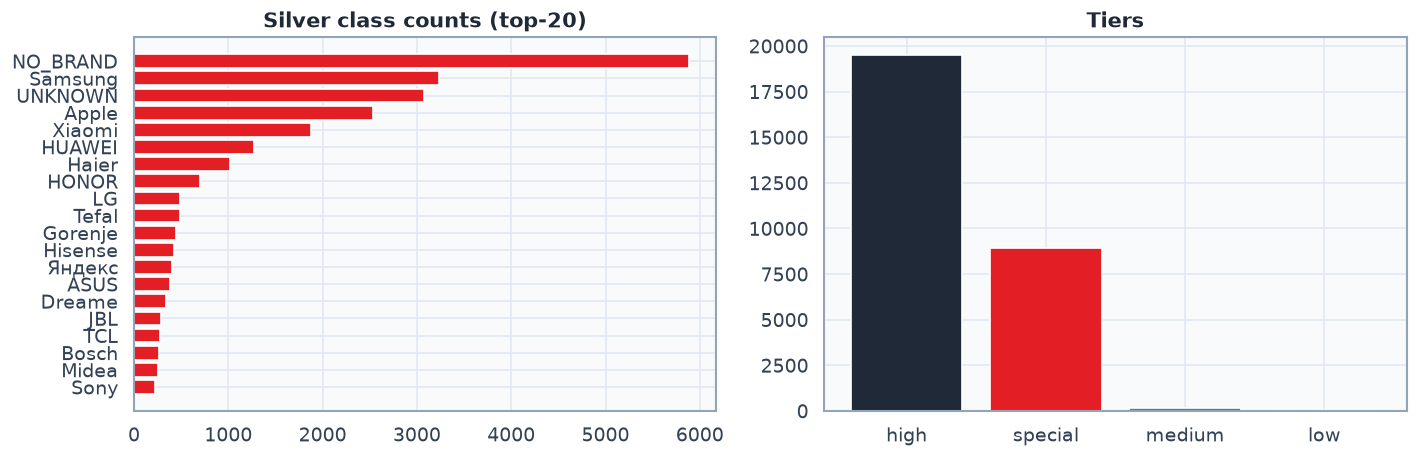

холодильник* labels:
brand
NO_BRAND    243
Haier        83
UNKNOWN      49
Indesit      32
Gorenje      31
Name: count, dtype: int64


,query_norm,brand,click_brand,label_reason
53,холодильник electrolux,Electrolux,Electrolux,brand_in_query
54,холодильник lg,LG,LG,brand_in_query
55,холодильники двухкамерные gorenje nrk6192axl4,Gorenje,Gorenje,brand_in_query
87,холодильники двухкамерные no frost beko 200 см,Beko,Beko,brand_in_query
147,холодильники haier,Haier,Haier,alias_hint
189,холодильники двухкамерные samsung,Samsung,Samsung,alias_hint
193,холодильники samsung,Samsung,Samsung,alias_hint
259,холодильники двухкамерные toshiba,Toshiba,Toshiba,alias_hint


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = silver["brand"].value_counts()
# top brands + specials
show = list(vc.head(20).index)
axes[0].barh([str(x) for x in show[::-1]], vc.loc[show].values[::-1], color=MVIDEO_RED)
axes[0].set_title("Silver class counts (top-20)")
tier_vc = silver["tier"].value_counts()
axes[1].bar(tier_vc.index.astype(str), tier_vc.values, color=[DARK_SLATE, MVIDEO_RED, MUTED, "#94A3B8"][: len(tier_vc)])
axes[1].set_title("Tiers")
fig.tight_layout()
fig.savefig(FIG / "04_silver_class_balance.png", dpi=140, bbox_inches="tight")
plt.show()

# sanity: холодильник не должен быть Indesit
bad = silver[silver["query_norm"].str.contains(r"холодильник", na=False)]
print("холодильник* labels:")
print(bad["brand"].value_counts().head())
display(bad[["query_norm", "brand", "click_brand", "label_reason"]].head(8))


## 7. Train / val split


In [12]:
def stratified_split(df, label_col, test_size, seed):
    rng = np.random.default_rng(seed)
    train_parts, val_parts = [], []
    for _, g in df.groupby(label_col, sort=False):
        idx = np.array(g.index, dtype=np.int64, copy=True)
        rng.shuffle(idx)
        if len(idx) == 1:
            train_parts.append(g)
            continue
        n_val = max(1, int(round(len(idx) * test_size)))
        val_parts.append(g.loc[idx[:n_val]])
        train_parts.append(g.loc[idx[n_val:]])
    return (
        pd.concat(train_parts).sample(frac=1, random_state=seed),
        pd.concat(val_parts).sample(frac=1, random_state=seed),
    )

vc = silver["brand"].value_counts()
keep = vc[vc >= max(MIN_PER_CLASS_TRAIN + 5, 20)].index
# specials всегда оставляем если есть хоть сколько-то
for sp in (LABEL_NO_BRAND, LABEL_UNKNOWN):
    if sp in vc.index and vc[sp] >= MIN_PER_CLASS_TRAIN:
        keep = keep.union(pd.Index([sp]))
data = silver[silver["brand"].isin(keep)].copy()
print(f"after min-class filter: {len(data):,} / {data['brand'].nunique()} classes")

train_df, val_df = stratified_split(data, "brand", VAL_SIZE, SEED)
tr_vc = train_df["brand"].value_counts()
ok = tr_vc[tr_vc >= MIN_PER_CLASS_TRAIN].index
train_df = train_df[train_df["brand"].isin(ok)].copy()
val_df = val_df[val_df["brand"].isin(ok)].copy()

label_list = sorted(train_df["brand"].unique(), key=lambda x: (x in {LABEL_NO_BRAND, LABEL_UNKNOWN}, x))
label2id = {b: i for i, b in enumerate(label_list)}
train_df["label_id"] = train_df["brand"].map(label2id)
val_df["label_id"] = val_df["brand"].map(label2id)
data = data[data["brand"].isin(ok)].copy()
data["label_id"] = data["brand"].map(label2id)

print(f"train={len(train_df):,}  val={len(val_df):,}  classes={len(label_list)}")
print("has NO_BRAND:", LABEL_NO_BRAND in label2id, "UNKNOWN:", LABEL_UNKNOWN in label2id)
display(train_df.sample(min(8, len(train_df)), random_state=0)[
    ["query_norm", "brand", "click_brand", "label_reason", "tier", "sample_weight"]
])


after min-class filter: 28,556 / 67 classes
train=22,846  val=5,710  classes=67
has NO_BRAND: True UNKNOWN: True


,query_norm,brand,click_brand,label_reason,tier,sample_weight
20712,вертикальный моющий пылесос remez,NO_BRAND,Remez,category_only,special,1.0
24159,подписка окко премиум,NO_BRAND,СберПрайм,category_only,special,1.0
26784,раска водно-дисперсионная parade краска фасадн...,UNKNOWN,Parade,ood_brand_surface,special,0.9
15861,смартфоны xiaomi 15 t,Xiaomi,Xiaomi,alias_hint,high,1.0
15676,honor 400 lite 12 512,HONOR,HONOR,alias_hint,high,1.0
431,встраиваемая посудомоечная машина krona брента...,Krona,Krona,brand_in_query,high,1.0
11717,кондиционер сплит 7 haier,Haier,Haier,alias_hint,high,1.0
18004,redmi note 12 4 g,Xiaomi,Krutoff,alias_hint,high,1.0


## 8. Inference helper (reference)

Эта функция — контракт для `07` / сервиса. Пороги = конфиг выше.


In [13]:
def should_call_brand_clf(
    *,
    ner_brand: str | None,
    query_norm: str,
    require_evidence: bool = REQUIRE_BRAND_EVIDENCE,
) -> tuple[bool, str]:
    """Решить, звать ли clf. ner_brand — уже найденный span/alias."""
    if ner_brand:
        return False, "ner_or_alias_span"
    co = category_only_score(query_norm)
    if co["is_category_only"]:
        return False, "category_only_skip"
    has_alias, _ = any_alias_in_query(query_norm)
    # surface любого top-brand / alias уже покрыт has_alias; без NER — clf на alias-хвосте
    if require_evidence and not has_alias and not co["has_modelish"]:
        # нет намёка на бренд/модель — не угадываем
        return False, "no_evidence_skip"
    return True, "call_clf"


def accept_brand_prediction(
    pred: str,
    proba: dict[str, float] | None,
    *,
    tau_accept: float = TAU_ACCEPT,
    tau_margin: float = TAU_MARGIN,
    tau_no_brand: float = TAU_NO_BRAND,
    tau_unknown: float = TAU_UNKNOWN,
) -> tuple[str | None, str]:
    """→ (brand or None, decision_reason). proba: label→probability."""
    p = float((proba or {}).get(pred, 0.0))
    if pred == LABEL_NO_BRAND:
        return (None, "pred_no_brand") if p >= tau_no_brand else (None, "reject_low_no_brand")
    if pred == LABEL_UNKNOWN:
        return (None, "pred_unknown_ood") if p >= tau_unknown else (None, "reject_low_unknown")
    # concrete brand
    if proba:
        top2 = sorted(proba.values(), reverse=True)[:2]
        margin = top2[0] - top2[1] if len(top2) > 1 else top2[0]
    else:
        margin = p
    if p >= tau_accept and margin >= tau_margin:
        return pred, "accept_brand"
    return None, "reject_low_confidence"


# smoke examples
examples = [
    "холодильник",
    "айфон 15",
    "наушники",
    "indesit стиральная",
    "tuf gaming a15",
]
print("should_call_brand_clf:")
for q in examples:
    qn = _norm_key(basic_clean(q))
    # имитация: alias как «NER»
    has_a, canon = any_alias_in_query(qn)
    ner = canon if has_a else None
    # если бренд явно в строке из top — тоже как ner
    call, reason = should_call_brand_clf(ner_brand=ner, query_norm=qn)
    print(f"  {q!r:30} ner={ner!s:10} call={call} ({reason})")

print("\naccept_brand_prediction smoke:")
print(accept_brand_prediction("Indesit", {"Indesit": 0.22, "Haier": 0.18, LABEL_NO_BRAND: 0.4}))
print(accept_brand_prediction(LABEL_NO_BRAND, {LABEL_NO_BRAND: 0.55, "Indesit": 0.1}))
print(accept_brand_prediction("Apple", {"Apple": 0.71, "Samsung": 0.05}))


should_call_brand_clf:
  'холодильник'                  ner=None       call=False (category_only_skip)
  'айфон 15'                     ner=Apple      call=False (ner_or_alias_span)
  'наушники'                     ner=None       call=False (category_only_skip)
  'indesit стиральная'           ner=None       call=False (no_evidence_skip)
  'tuf gaming a15'               ner=None       call=True (call_clf)

accept_brand_prediction smoke:
(None, 'reject_low_confidence')
(None, 'pred_no_brand')
('Apple', 'accept_brand')


## 9. Сохранение артефактов + policy

In [14]:
cols = [
    "query_norm", "query_raw", "brand", "click_brand", "label_id", "label_reason",
    "confidence", "sample_weight", "n_clicks", "n_brands",
    "brand_in_query", "has_alias", "is_category_only", "tier",
    "runner_up", "weight_margin",
]

inference_policy = {
    "cascade": [
        "1. If NER/dicts/alias yields BRAND → use it; do NOT call clf",
        "2. If category-only → brand=null (NO_BRAND); do NOT call clf",
        "3. Else if brand-evidence (alias or modelish) → call clf",
        "4. Else → brand=null; do NOT call clf",
    ],
    "thresholds": {
        "TAU_ACCEPT": TAU_ACCEPT,
        "TAU_MARGIN": TAU_MARGIN,
        "TAU_NO_BRAND": TAU_NO_BRAND,
        "TAU_UNKNOWN": TAU_UNKNOWN,
        "REQUIRE_BRAND_EVIDENCE": REQUIRE_BRAND_EVIDENCE,
    },
    "special_labels": {
        "NO_BRAND": "no brand implied; output brand=null",
        "UNKNOWN": "OOD / ambiguous; output brand=null + optional retrieval",
    },
    "accept_rules": [
        "pred in brands and P>=TAU_ACCEPT and margin>=TAU_MARGIN → accept",
        "pred==NO_BRAND and P>=TAU_NO_BRAND → brand=null",
        "pred==UNKNOWN and P>=TAU_UNKNOWN → brand=null (ood)",
        "else → reject brand=null",
    ],
}

stats = {
    "sample_n_clicks": int(SAMPLE_N),
    "seed": SEED,
    "top_k": TOP_K_BRANDS,
    "min_confidence": MIN_CONFIDENCE,
    "n_agg_queries": int(len(feat)),
    "n_silver": int(len(silver)),
    "n_train": int(len(train_df)),
    "n_val": int(len(val_df)),
    "n_classes": int(len(label_list)),
    "label_reason_counts": lab["label_reason"].value_counts().to_dict(),
    "no_brand_share": float((silver["brand"] == LABEL_NO_BRAND).mean()),
    "unknown_share": float((silver["brand"] == LABEL_UNKNOWN).mean()),
    "category_only_in_agg": float(feat["is_category_only"].mean()),
    "thresholds": inference_policy["thresholds"],
}

if SAVE:
    train_df[cols].to_parquet(OUT / "silver_brand_train.parquet", index=False)
    val_df[cols].to_parquet(OUT / "silver_brand_val.parquet", index=False)
    data[cols].to_parquet(OUT / "silver_brand_all.parquet", index=False)
    with open(OUT / "label_map.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "label2id": label2id,
                "id2label": {str(i): b for b, i in label2id.items()},
                "special": [LABEL_NO_BRAND, LABEL_UNKNOWN],
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
    with open(OUT / "inference_policy.json", "w", encoding="utf-8") as f:
        json.dump(inference_policy, f, ensure_ascii=False, indent=2)
    save_stats(stats, OUT / "silver_brand_stats.json")
    train_df[cols].head(500).to_csv(OUT / "silver_brand_train_preview.csv", index=False)
    print("saved →", OUT)
else:
    print("SAVE=False")

print(json.dumps(stats, ensure_ascii=False, indent=2))


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf\silver_brand_stats.json
saved → D:\Projects-26-06-2026\mvideo-ner-search\artifacts\brand_clf
{
  "sample_n_clicks": 400000,
  "seed": 42,
  "top_k": 80,
  "min_confidence": 0.55,
  "n_agg_queries": 63267,
  "n_silver": 28664,
  "n_train": 22846,
  "n_val": 5710,
  "n_classes": 67,
  "label_reason_counts": {
    "no_evidence_drop": 29290,
    "alias_hint": 10996,
    "brand_in_query": 8764,
    "category_only": 7108,
    "ood_brand_surface": 6099,
    "ambiguous_clicks": 932,
    "low_conf_with_evidence": 62,
    "other_drop": 16
  },
  "no_brand_share": 0.20513536142897013,
  "unknown_share": 0.10713787329053866,
  "category_only_in_agg": 0.1123492500039515,
  "thresholds": {
    "TAU_ACCEPT": 0.42,
    "TAU_MARGIN": 0.08,
    "TAU_NO_BRAND": 0.35,
    "TAU_UNKNOWN": 0.3,
    "REQUIRE_BRAND_EVIDENCE": true
  }
}


## 10. Вердикт

### Что изменилось
- `NO_BRAND` для category-only (`холодильник`)  
- `UNKNOWN` для OOD / низкого conf  
- дроп brand_absent без evidence (больше не кормим Indesit-prior)  
- `inference_policy.json` с cascade и τ  

### Как учить `07`
```python
train = pd.read_parquet("../artifacts/brand_clf/silver_brand_train.parquet")
# y включает NO_BRAND / UNKNOWN
# на инференсе — should_call_brand_clf + accept_brand_prediction
```

### Метрики смотреть отдельно
1. Accuracy / F1 на **brand-present**  
2. **False brand rate** на category-only (цель → 0)  
3. Reject rate и калибровка τ на mini-gold  

Gold позже: stratified по `label_reason` × tier.
